# Zadanie: pingwiny

Wykorzystaj zbiór penguins.csv (pobierz), w którym są cechy dla różnych gatunków pingwinów, wykonaj eksploracje, a następnie naucz poznane w tym module modele.

Import bibliotek i danych.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from matplotlib.colors import ListedColormap
from scipy import stats

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [2]:
penguins = pd.read_csv('penguins.csv')

In [3]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        344 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 13.6 KB


usunięcie pustych lub brakujących wierszy.

In [4]:
penguins = penguins.dropna()

In [5]:
penguins.info()

<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        342 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.0 KB


sprawdzenie proporcji danych

In [6]:
penguins['Species'].value_counts(normalize=True).round(2)

Species
0    0.44
1    0.36
2    0.20
Name: proportion, dtype: float64

In [7]:
penguins.describe()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,0.757310
std,5.459584,1.974793,14.061714,801.954536,0.763648
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.225000,15.600000,190.000000,3550.000000,0.000000
50%,44.450000,17.300000,197.000000,4050.000000,1.000000
75%,48.500000,18.700000,213.000000,4750.000000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,2.000000


podzielenie danych na zbiór treningowy i testowy z zachowaniem proporcji gatunków w zbiorach.

In [8]:
features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']
target = 'Species'
X, y = penguins[features], penguins[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, stratify=y)

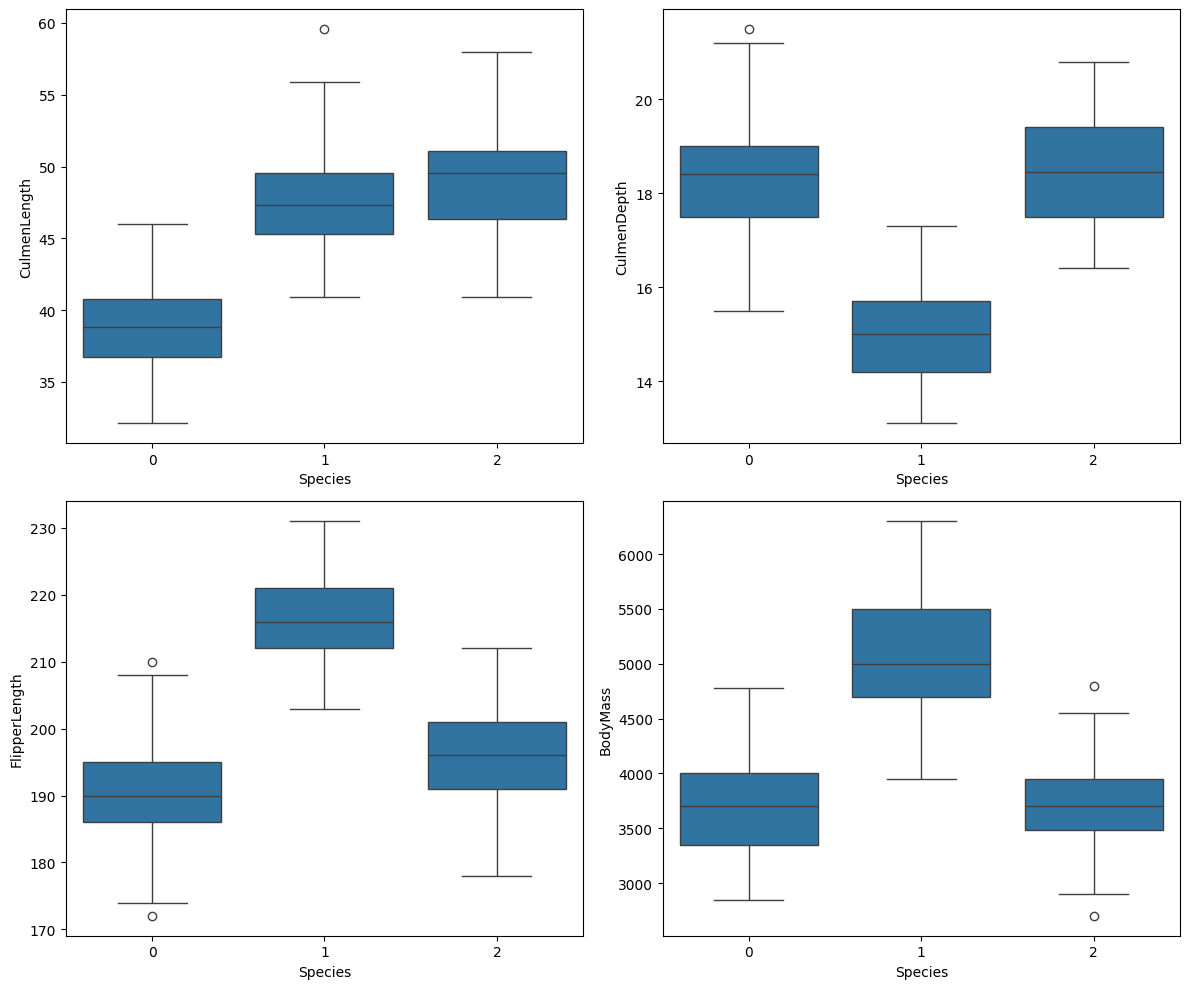

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(features):
    sns.boxplot(data=penguins, x='Species', y=col, ax=axes[i//2, i%2])
plt.tight_layout()
plt.show()

Pojedyńcze wartości odstające pokazują brak ewidentnych błędow w danych.

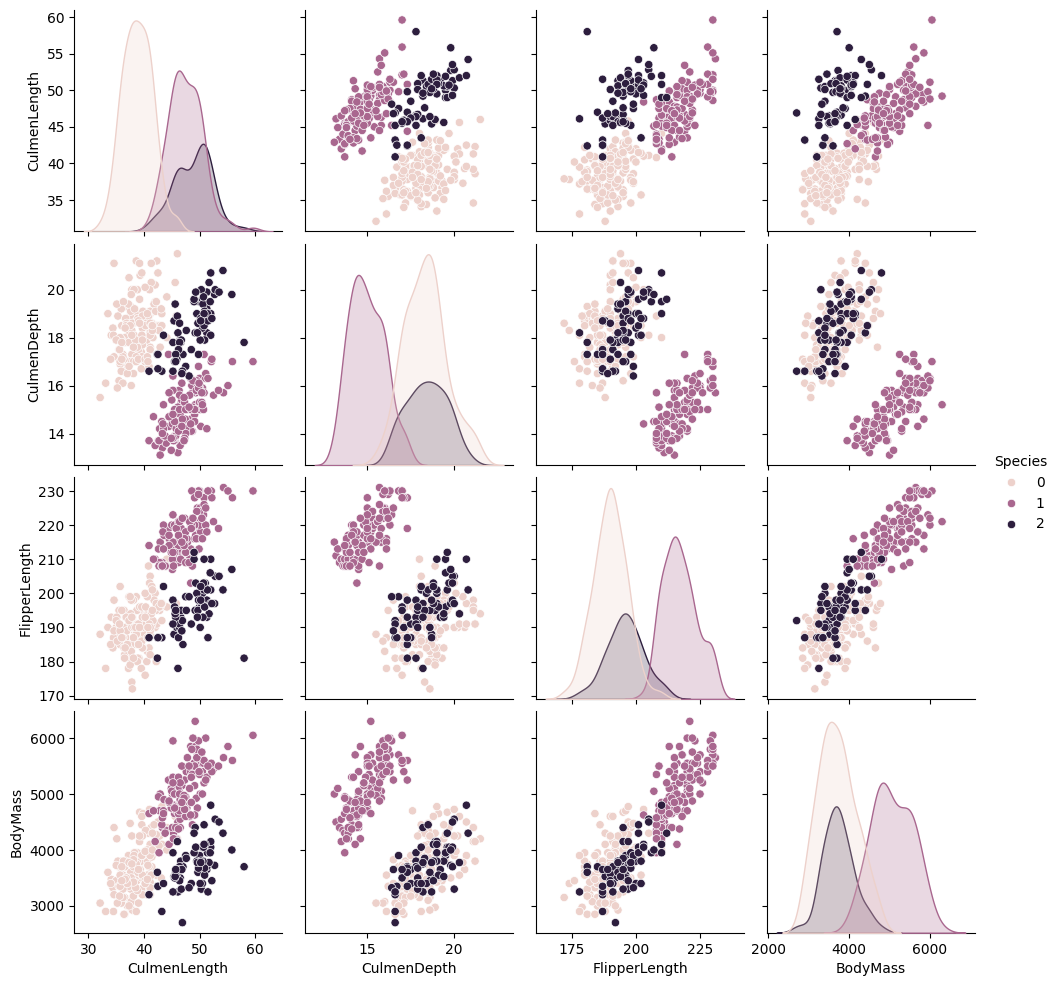

In [10]:
sns.pairplot(penguins, hue='Species')
plt.show()

Z wykresów łatwo zauważyć że gatunek 1 jest w wielu aspektach odmienne od 0 i 2. Model nie powinien mieć problemów z odróżnieniem go od reszty, błędy mogą pojawiać się podczas rozróżniania 0 i 2, szczególnie że w zbiorze gatunek 2 jest najmniejszy i jego udział w danych to 20%. 

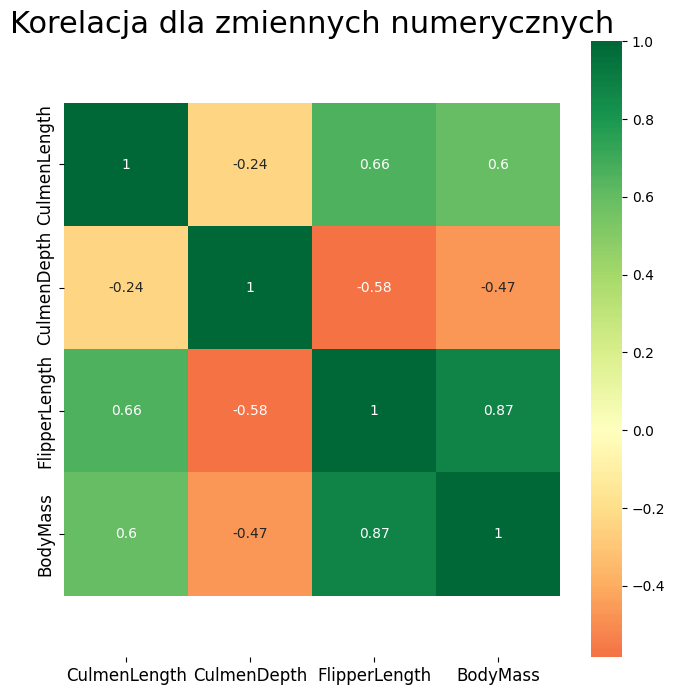

In [11]:
plt.figure(figsize=(8, 8))
ax = sns.heatmap(X.corr(),
                 xticklabels=X.corr().columns,
                 yticklabels=X.corr().columns,
                 cmap='RdYlGn',
                 center=0,
                 annot=True)

plt.title('Korelacja dla zmiennych numerycznych', fontsize=22)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Mimo że łatwo zauważyć i zrozumieć korelacje między BodyMass a FlipperLength to postanowiłem nie usuwać żadnej z tych danych. 

Standaryzacja zbiorów danych została tu zamieniona na pipline skalujacy oraz stosujacy PCA.

In [13]:
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42))
])

preprocessor = ColumnTransformer(transformers=[('num', num_pipeline, features)])

X_train_standardized = preprocessor.fit_transform(X_train)
X_test_standardized  = preprocessor.transform(X_test)
print(f"Liczba komponentów przed  PCA: {X_train.shape[1]}")
print(f"Liczba komponentów po PCA: {X_train_standardized.shape[1]}")

Liczba komponentów przed  PCA: 4
Liczba komponentów po PCA: 3


# Model 1: KNN

Raport klasyfikacji dla modelu KNN:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        45
           1       1.00      1.00      1.00        37
           2       1.00      0.90      0.95        21

    accuracy                           0.98       103
   macro avg       0.99      0.97      0.98       103
weighted avg       0.98      0.98      0.98       103



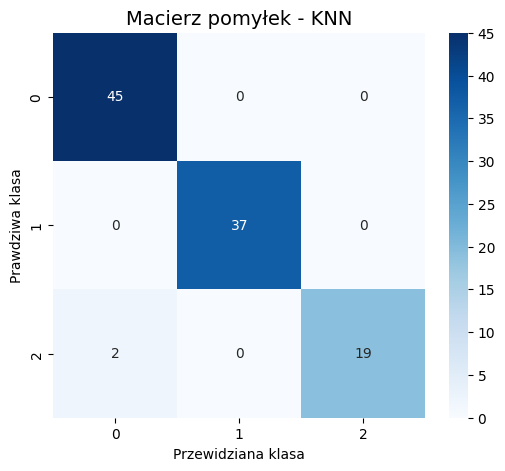

In [14]:
model_knn = KNeighborsClassifier(n_neighbors= int(X_train_standardized.shape[0]*0.05))
model_knn.fit(X_train_standardized, y_train)
y_pred_knn = model_knn.predict(X_test_standardized)

print("Raport klasyfikacji dla modelu KNN:")
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_knn.classes_, yticklabels=model_knn.classes_)

plt.title('Macierz pomyłek - KNN', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# Model 2: Drzewo decyzyjne

Raport klasyfikacji dla modelu Drzewo decyzyjne:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        45
           1       1.00      0.97      0.99        37
           2       0.90      0.86      0.88        21

    accuracy                           0.95       103
   macro avg       0.95      0.94      0.94       103
weighted avg       0.95      0.95      0.95       103



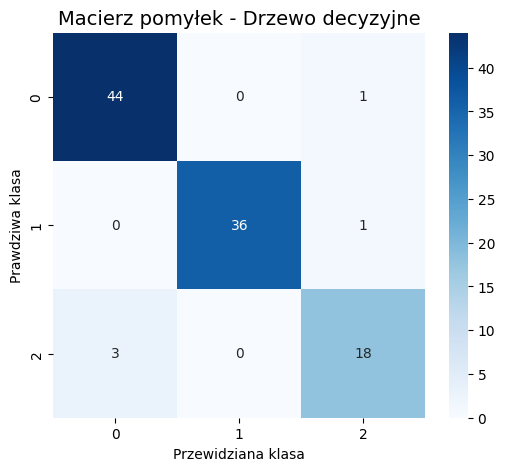

In [15]:
model_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=int(X_train.shape[0]*0.05))
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

print("Raport klasyfikacji dla modelu Drzewo decyzyjne:")
print(classification_report(y_test, y_pred_tree))
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_tree.classes_, yticklabels=model_tree.classes_)

plt.title('Macierz pomyłek - Drzewo decyzyjne', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# Model 3: SVC

Raport klasyfikacji dla modelu SVC:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       1.00      1.00      1.00        37
           2       0.95      0.95      0.95        21

    accuracy                           0.98       103
   macro avg       0.98      0.98      0.98       103
weighted avg       0.98      0.98      0.98       103



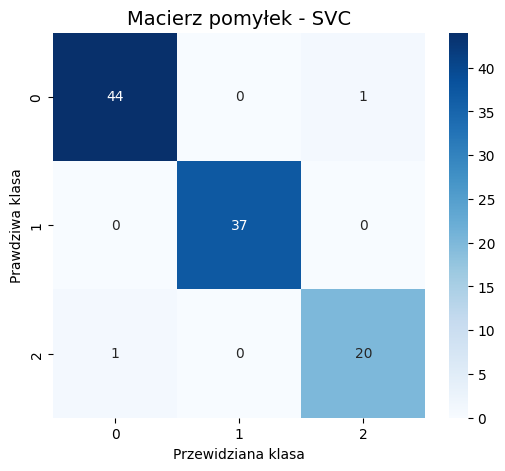

In [16]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', probability=True)
model_svm.fit(X_train_standardized, y_train)
y_pred_svm = model_svm.predict(X_test_standardized)
print("Raport klasyfikacji dla modelu SVC:")
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_svm.classes_, yticklabels=model_svm.classes_)

plt.title('Macierz pomyłek - SVC', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# Model 4: Las losowy

Raport klasyfikacji dla modelu RandomForest:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



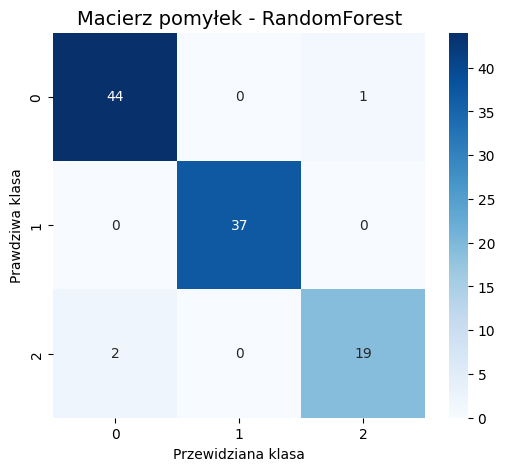

In [17]:

model_forest = RandomForestClassifier(n_estimators=1000, max_depth=3, min_samples_leaf=int(X_train.shape[0]*0.05))
model_forest.fit(X_train, y_train)
y_pred_forest = model_forest.predict(X_test)
print("Raport klasyfikacji dla modelu RandomForest:")
print(classification_report(y_test, y_pred_forest))

cm = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_forest.classes_, yticklabels=model_forest.classes_)

plt.title('Macierz pomyłek - RandomForest', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# Model 5: AdaBoost

Raport klasyfikacji dla modelu AdaBoost:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       1.00      1.00      1.00        37
           2       0.91      0.95      0.93        21

    accuracy                           0.97       103
   macro avg       0.96      0.97      0.97       103
weighted avg       0.97      0.97      0.97       103



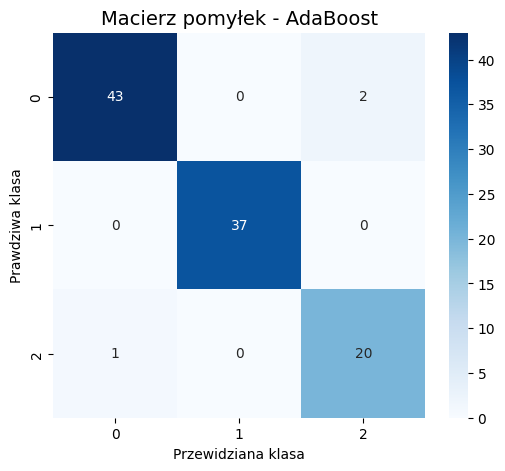

In [18]:
model_adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50)
model_adaboost.fit(X_train, y_train)
y_pred_adaboost = model_adaboost.predict(X_test)
print("Raport klasyfikacji dla modelu AdaBoost:")
print(classification_report(y_test, y_pred_adaboost))

cm = confusion_matrix(y_test, y_pred_adaboost)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_adaboost.classes_, yticklabels=model_adaboost.classes_)

plt.title('Macierz pomyłek - AdaBoost', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# Porównanie wyników modeli

In [19]:
models_results = {'KNN': y_pred_knn, 'Decision Tree': y_pred_tree, 'SVM': y_pred_svm, 'Random Forest': y_pred_forest, 'AdaBoost': y_pred_adaboost}
comparison = []
for name, y_pred in models_results.items():
    comparison.append({'Model': name, 'Accuracy': accuracy_score(y_test, y_pred), 
    'Precision': precision_score(y_test, y_pred, average='macro'),
    'Recall': recall_score(y_test, y_pred, average='macro'), 'F1-score': f1_score(y_test, y_pred, average='macro'), 
    'Liczba pomyłek': (y_test != y_pred).sum()})


df_comparison = pd.DataFrame(comparison)
df_comparison = df_comparison.sort_values(by='Accuracy', ascending=False).round(4)

print("PORÓWNANIE MODELI")

df_comparison = df_comparison.round(4)
df_comparison = df_comparison.set_index('Model')
print(df_comparison.to_string())

PORÓWNANIE MODELI
               Accuracy  Precision  Recall  F1-score  Liczba pomyłek
Model                                                               
KNN              0.9806     0.9858  0.9683    0.9761               2
SVM              0.9806     0.9767  0.9767    0.9767               2
Random Forest    0.9709     0.9688  0.9608    0.9646               3
AdaBoost         0.9709     0.9621  0.9693    0.9655               3
Decision Tree    0.9515     0.9454  0.9360    0.9403               5


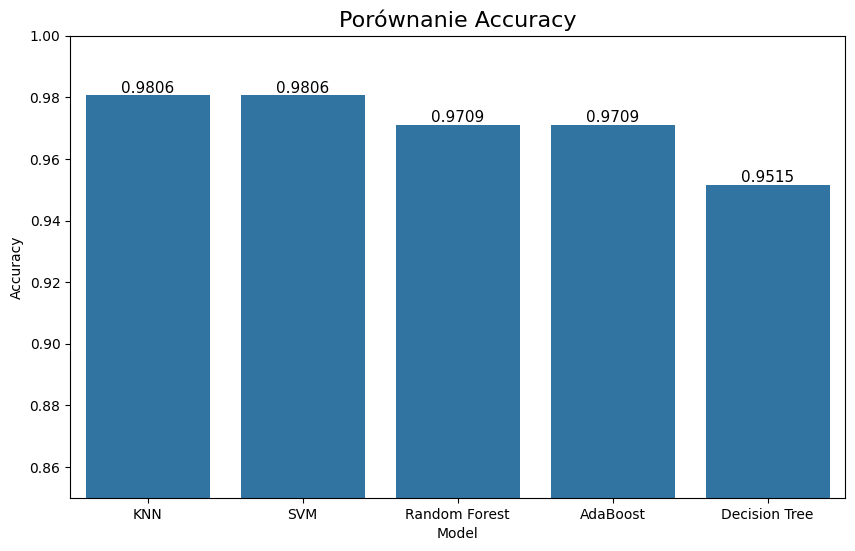

In [20]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_comparison, x='Model', y='Accuracy')

plt.title('Porównanie Accuracy', fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0.85, 1.0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)

plt.show()

Jak widać model KNN mimo swojej prostoty poradził sobie lepiej od bardziej zaawansowanych, co warto zapamiętać by nie popaść w chęć używania jak najbardziej zaawansowanych narzędzi nawet do relatywnie prostych problemów. Błędy w klasie 2 wynikają z zatartej granicy między klasami 0 i 2, a biorąc pod uwagę że w zbiorze treningowym klasy 0 jest dwa razy więcej od klasy 2, większość przypadków "niepewnych" trafia do klasy 0 